In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [24]:
df = pd.read_csv("Algerian_forest_fires_cleaned_dataset.csv")

In [25]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [26]:
df.drop(['day','month','year'],axis=1,inplace = True)

In [27]:
#Encoding
df['Classes']= np.where(df['Classes'].str.contains("not fire"),0,1)

In [28]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [29]:
df['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

In [30]:
#Independent and Dependent Features
X = df.drop('FWI',axis=1)
y =df['FWI']

In [31]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test  = train_test_split(X,y,test_size=0.25,random_state=42)

In [32]:
X_train.corr

<bound method DataFrame.corr of      Temperature  RH  Ws  Rain  FFMC   DMC    DC   ISI   BUI  Classes  Region
97            29  74  19   0.1  75.8   3.6  32.2   2.1   5.6        0       0
141           31  72  14   0.2  60.2   3.8   8.0   0.8   3.7        0       1
192           40  31  15   0.0  94.2  22.5  46.3  16.6  22.4        1       1
68            32  60  18   0.3  77.1  11.3  47.0   2.2  14.1        0       0
119           32  47  14   0.7  77.5   7.1   8.8   1.8   6.8        0       0
..           ...  ..  ..   ...   ...   ...   ...   ...   ...      ...     ...
106           24  82  15   0.4  44.9   0.9   7.3   0.2   1.4        0       0
14            28  80  17   3.1  49.4   3.0   7.4   0.4   3.0        0       0
92            25  76  17   7.2  46.0   1.3   7.5   0.2   1.8        0       0
179           34  59  16   0.0  88.1  19.5  47.2   7.4  19.5        1       1
102           30  77  21   1.8  58.5   1.9   8.4   1.1   2.4        0       0

[182 rows x 11 columns]>

<Axes: >

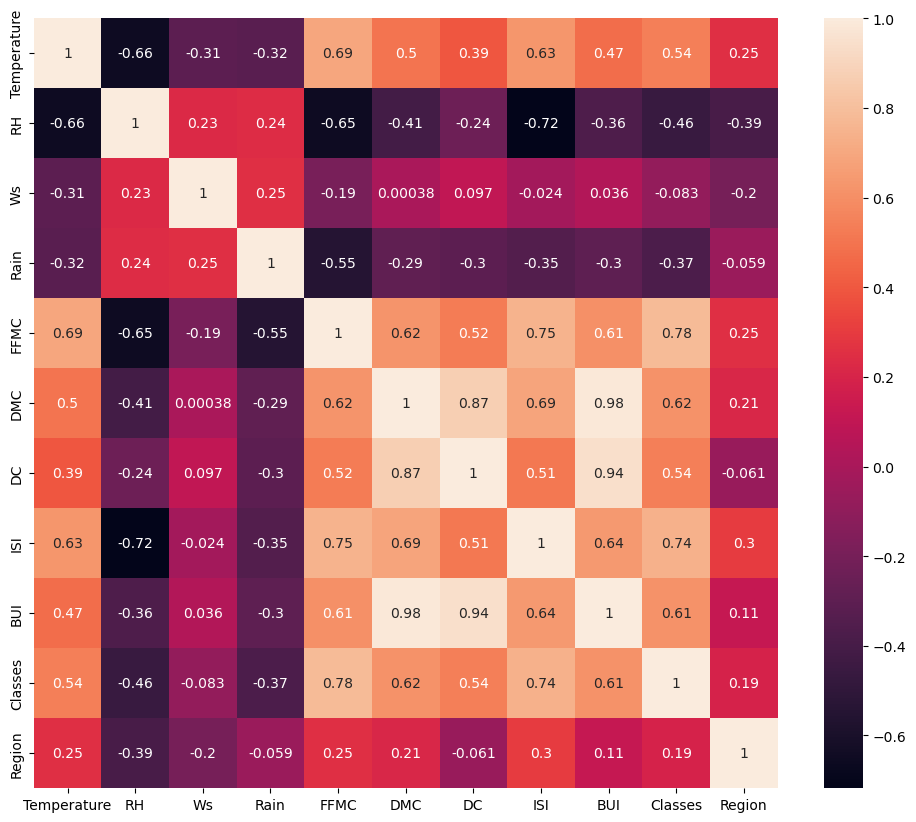

In [33]:
plt.figure(figsize=(12,10))
corr = X_train.corr()
sns.heatmap(corr,annot=True)

In [34]:
def correlation(dataset,threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j])>threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [35]:
#Threshold -Domain Expertise
corr_features = correlation(X_train,0.85)

In [36]:
X_train.drop(corr_features,axis=1)

,Temperature,RH,Ws,Rain,FFMC,DMC,ISI,Classes,Region
97,29,74,19,0.1,75.8,3.6,2.1,0,0
141,31,72,14,0.2,60.2,3.8,0.8,0,1
192,40,31,15,0.0,94.2,22.5,16.6,1,1
68,32,60,18,0.3,77.1,11.3,2.2,0,0
119,32,47,14,0.7,77.5,7.1,1.8,0,0
...,...,...,...,...,...,...,...,...,...
106,24,82,15,0.4,44.9,0.9,0.2,0,0
14,28,80,17,3.1,49.4,3.0,0.4,0,0
92,25,76,17,7.2,46.0,1.3,0.2,0,0
179,34,59,16,0.0,88.1,19.5,7.4,1,1


In [37]:
#Feature Scaling or Standardization

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

 Model Training 
 Linear Regression model

MAE: 0.46544608000941023
R2 Score :  0.98938502949221


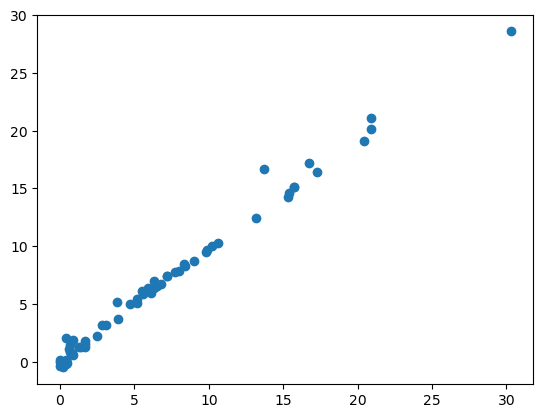

In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
reg = LinearRegression()
reg.fit(X_train_scaled,y_train)
y_pred = reg.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("MAE:" ,mae)
print("R2 Score : ",score)
plt.scatter(y_test,y_pred)

MAE: 1.0816323165898811
R2 Score :  0.9548117077009715


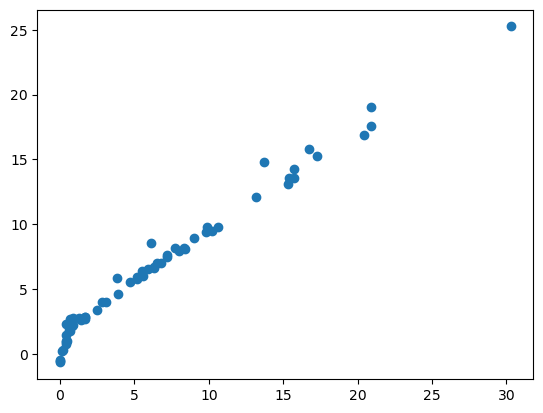

In [39]:
#Lasso Regression
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
lasso = Lasso()
lasso.fit(X_train_scaled,y_train)
y_pred = lasso.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("MAE:" ,mae)
print("R2 Score : ",score)
plt.scatter(y_test,y_pred)

MAE: 0.5053525521628106
R2 Score :  0.9873482065539132


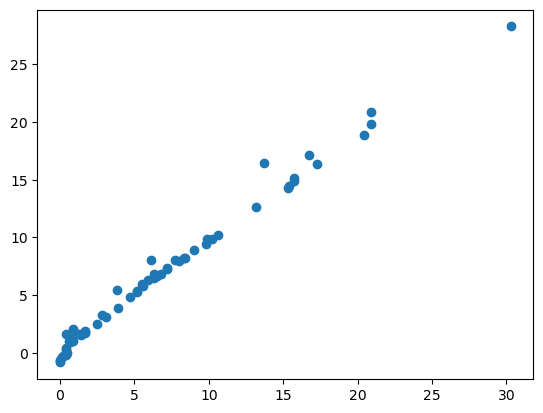

In [40]:
#LassoCV
from sklearn.linear_model import LassoCV
lassocv = LassoCV(cv=5)
lassocv.fit(X_train_scaled,y_train)
y_pred = lassocv.predict(X_test_scaled)
plt.scatter(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("MAE:" ,mae)
print("R2 Score : ",score)

MAE: 0.503285697341683
R2 Score :  0.9871729594175268


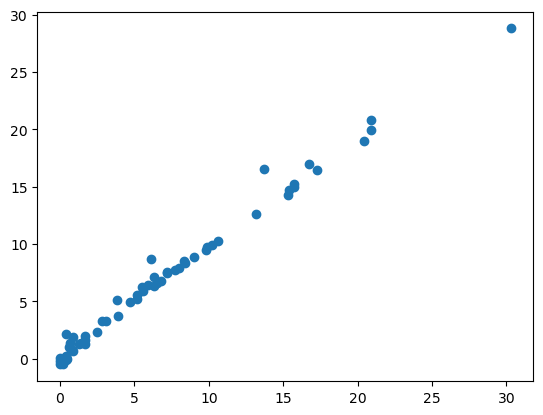

In [41]:
#RidgeCV
from sklearn.linear_model import RidgeCV
ridgeCV = RidgeCV(cv=5)
ridgeCV.fit(X_train_scaled,y_train)
y_pred = ridgeCV.predict(X_test_scaled)
plt.scatter(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("MAE:" ,mae)
print("R2 Score : ",score)

MAE: 0.503285697341683
R2 Score :  0.9871729594175268


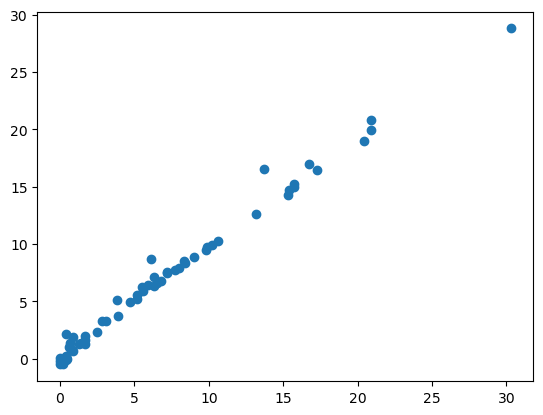

In [42]:
#Ridge Regression
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
ridge = Ridge()
ridge.fit(X_train_scaled,y_train)
y_pred = ridge.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("MAE:" ,mae)
print("R2 Score : ",score)
plt.scatter(y_test,y_pred)

MAE: 1.6830954467418582
R2 Score :  0.900671789556956


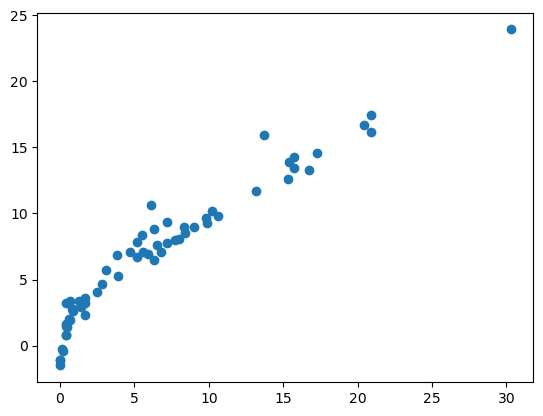

In [43]:
#ElasticNet Regression
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
en = ElasticNet()
en.fit(X_train_scaled,y_train)
y_pred = en.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("MAE:" ,mae)
print("R2 Score : ",score)
plt.scatter(y_test,y_pred)

MAE: 0.5891683480603581
R2 Score :  0.9833493614806597


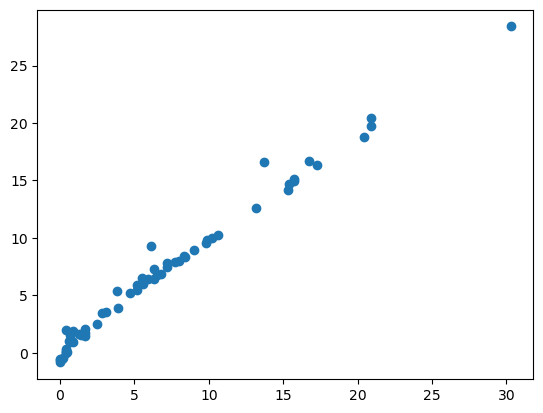

In [44]:
#ElasticNetCV
from sklearn.linear_model import ElasticNetCV
elasticnetcv = ElasticNetCV(cv=5)
elasticnetcv.fit(X_train_scaled,y_train)
y_pred = elasticnetcv.predict(X_test_scaled)
plt.scatter(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("MAE:" ,mae)
print("R2 Score : ",score)

In [45]:
import pickle
pickle.dump(scaler,open("scaler.pkl","wb"))
pickle.dump(ridge,open("ridge.pkl","wb"))